# Credit Default Prediction - Exploratory Data Analysis

## Objective

The objective of this project is to analyze customer financial data in order to understand the key factors driving credit default risk.

Through exploratory data analysis (EDA), we aim to:
- Understand the structure and distribution of the data
- Identify patterns and relationships between variables
- Detect potential risk indicators of default
- Prepare the data for predictive modeling

## Dataset Overview

The dataset contains information about customers’ financial situation, including income, debt levels, credit behavior, and creditworthiness indicators.

Each observation represents a customer, with the target variable:

- **default**:  
  - 0 → No default  
  - 1 → Default  

## Analysis Plan

The exploratory analysis is structured as follows:

1. **Data Understanding**
   - Dataset structure
   - Variable types
   - Missing values

2. **Univariate Analysis**
   - Distribution of key numerical variables
   - Identification of skewness and outliers

3. **Target Analysis**
   - Distribution of default vs non-default customers
   - Class imbalance assessment

4. **Bivariate Analysis**
   - Comparison between default and non-default groups
   - Identification of key discriminating variables

5. **Feature Relationships**
   - Scatter plots to explore relationships between variables
   - Detection of trends and patterns

6. **Correlation Analysis**
   - Identification of relationships between variables
   - Detection of multicollinearity

7. **Feature Engineering Insights**
   - Log transformations
   - Ratio analysis (e.g., debt-to-income)

## Key Questions

Throughout this analysis, we aim to answer the following questions:

- What differentiates customers who default from those who do not?
- Which variables are the strongest predictors of default risk?
- Are there redundant or highly correlated features?
- How can we transform the data to improve model performance?

## Next Step

The insights derived from this exploratory analysis will be used to build and evaluate predictive models for credit default.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Understanding

Before conducting the exploratory analysis, it is essential to understand the structure and content of the dataset.

This step aims to:
- Identify the variables and their types
- Understand the meaning of each feature
- Assess the overall data quality (missing values, consistency)
- Get an initial overview of the dataset size and structure

The dataset contains information about customers’ financial profiles, including income, debt levels, credit behavior, and creditworthiness indicators.

Each row represents a unique customer, and the target variable **default** indicates whether the customer has defaulted on their loan.

This initial understanding provides the foundation for all subsequent analyses.

### 1.1 Dataset structure and Variable types

In [2]:
df = pd.read_csv("../data/raw/Loan_data.csv")

print("-----HEAD-----\n")
print(df.head())

-----HEAD-----

   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  


In [3]:
print("\n-----INFO-----\n")
print(df.info())


-----INFO-----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None


In [4]:
print("\n-----DESCRIBE-----\n")
print(df.describe())


-----DESCRIBE-----

        customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count  1.000000e+04              10000.000000          10000.000000   
mean   4.974577e+06                  1.461200           4159.677034   
std    2.293890e+06                  1.743846           1421.399078   
min    1.000324e+06                  0.000000             46.783973   
25%    2.977661e+06                  0.000000           3154.235371   
50%    4.989502e+06                  1.000000           4052.377228   
75%    6.967210e+06                  2.000000           5052.898103   
max    8.999789e+06                  5.000000          10750.677810   

       total_debt_outstanding         income  years_employed    fico_score  \
count            10000.000000   10000.000000    10000.000000  10000.000000   
mean              8718.916797   70039.901401        4.552800    637.557700   
std               6627.164762   20072.214143        1.566862     60.657906   
min                 31.6527

**Dataset Variables Description:**

- **customer_id**  
  Unique identifier assigned to each customer. This variable does not carry predictive information and is mainly used for identification purposes.

- **credit_lines_outstanding**  
  Number of active credit lines (e.g., credit cards, loans) currently held by the customer. A higher number may indicate greater access to credit but also potential overexposure to debt.

- **loan_amt_outstanding**  
  Current outstanding amount of the loan taken by the customer. This represents how much remains to be repaid on the specific loan being analyzed.

- **total_debt_outstanding**  
  Total amount of debt the customer currently owes across all credit sources. This includes the loan amount and other liabilities, reflecting the overall financial burden.

- **income**  
  Annual income of the customer. Higher income generally suggests a greater ability to repay debt and lower default risk.

- **years_employed**  
  Number of years the customer has been employed. This can be a proxy for financial stability and job security.

- **fico_score**  
  Credit score of the customer, typically ranging from 300 to 850. It reflects the customer’s creditworthiness, where higher scores indicate lower risk of default.

- **default**  
  Target variable indicating whether the customer defaulted on the loan.  
  - 0 = No default  
  - 1 = Default

**Descriptive Statistics :**

The dataset contains **10,000 observations** across all variables, with no missing values.

Key insights from the descriptive statistics:

- **Income** is centered around **70,000**, with most customers earning between **56,000 and 83,000**.
- **FICO score** has an average of **~638**, indicating a generally moderate credit profile across customers.
- **Total debt outstanding** shows high variability, with a median of **~6,700** and a maximum exceeding **43,000**, suggesting the presence of significant outliers.
- **Loan amount outstanding** is more concentrated, with a median around **4,000**.
- **Years employed** averages **4.5 years**, indicating moderate employment stability.
- The **default rate is approximately 18.5%**, confirming a moderately imbalanced dataset.

Overall, the data appears consistent, with realistic ranges and no immediate data quality issues.

### 1.2 Missing values

In [12]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

The dataset contains **no missing values** across all variables. Each feature has a complete set of 10,000 observations, indicating high data quality and consistency.

As a result, no imputation or data cleaning related to missing values is required before proceeding to further analysis or modeling.

## 2. Univariate Analysis

This section focuses on analyzing each variable individually to understand its distribution and key characteristics.

The goal is to:
- Identify the shape of the distributions (normal, skewed, etc.)
- Detect potential outliers
- Understand the range and variability of each feature

We primarily use histograms and boxplots to visualize the distributions of numerical variables such as income, debt, loan amount, and FICO score.

This step provides essential insights into the behavior of each variable and helps guide further analysis, including transformations and feature engineering.

### 2.1 Distribution of key numerical variables

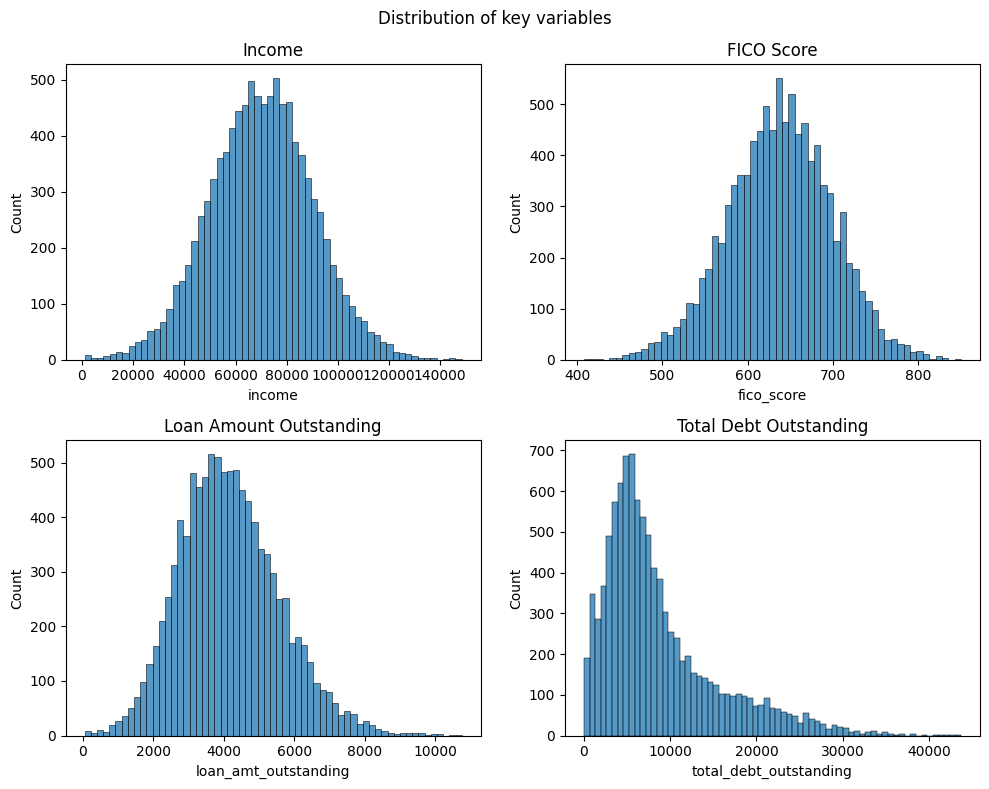

In [121]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

sns.histplot(df["income"], ax=axes[0,0])
sns.histplot(df["fico_score"], ax=axes[0,1])
sns.histplot(df["loan_amt_outstanding"], ax=axes[1,0])
sns.histplot(df["total_debt_outstanding"], ax=axes[1,1])

axes[0,0].set_title("Income")
axes[0,1].set_title("FICO Score")
axes[1,0].set_title("Loan Amount Outstanding")
axes[1,1].set_title("Total Debt Outstanding")

fig.suptitle("Distribution of key variables")

plt.tight_layout()
plt.show()


The histograms above provide an overview of the distribution of the main numerical variables in the dataset.

**Income :** The income distribution appears approximately normal, centered around 70,000. Most customers earn between 50,000 and 90,000, with relatively few extreme values. This suggests a fairly homogeneous population in terms of income.

**FICO Score :** The FICO score also follows a near-normal distribution, centered around 630–650. This indicates that the majority of customers have an average credit score, with fewer individuals at very low or very high credit levels.

**Loan Amount Outstanding :** The loan amount outstanding shows a slightly right-skewed distribution. Most loans are concentrated between 2,500 and 6,000, with fewer high-value loans. This suggests that the majority of customers have moderate loan exposure.

**Total Debt Outstanding :** The total debt outstanding is strongly right-skewed. Most customers have relatively low to moderate total debt, but a small number of individuals carry very high levels of debt. These extreme values (outliers) may be particularly important when analyzing default risk.

**Key Insights :**
- Most variables follow relatively smooth distributions, with limited noise.
- Total debt stands out as the most skewed variable, indicating potential outliers.
- The dataset appears well-behaved and suitable for modeling, with no obvious data quality issues.

These observations will guide further analysis, particularly when comparing default vs non-default customers.

### 2.2 Outliers Analysis (Total Debt Outstanding)

In this section, we focus on identifying potential outliers in the **total_debt_outstanding** variable.

Given the skewed distribution observed earlier, it is important to detect extreme values that may impact both the analysis and the performance of predictive models.

We first visualize the distribution using a boxplot, then apply the **Interquartile Range (IQR) method** to quantitatively identify outliers.

This approach helps highlight unusually high debt levels, which may represent high-risk customers or extreme financial situations.

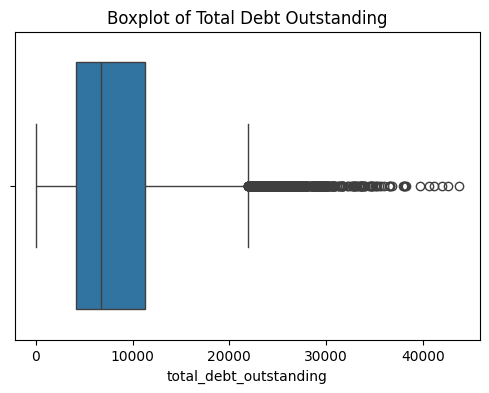

In [103]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["total_debt_outstanding"])
plt.title("Boxplot of Total Debt Outstanding")
plt.show()

In [104]:
Q1 = df["total_debt_outstanding"].quantile(0.25)
Q3 = df["total_debt_outstanding"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["total_debt_outstanding"] < lower_bound) | 
              (df["total_debt_outstanding"] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 602


In [105]:
print("Percentage of outliers:", len(outliers)/len(df)*100)

Percentage of outliers: 6.02


The distribution of total_debt_outstanding is highly right-skewed, as shown by the boxplot. A significant number of extreme values can be observed, indicating the presence of outliers on the upper end of the distribution.

Using the IQR method, we identified 602 outliers, representing a notable portion of the dataset (6.02%). These extreme values suggest that a small group of customers holds disproportionately high levels of debt.

Such outliers may impact model performance, especially for models sensitive to data distribution like logistic regression.

## 3. Target Analysis

This section focuses on analyzing the distribution of the target variable **default**.

Understanding the balance between defaulting and non-defaulting customers is essential, as it directly impacts model training and evaluation.

The dataset shows that approximately **18.5% of customers default**, while **81.5% do not**, indicating a moderately imbalanced dataset.

This imbalance suggests that relying solely on accuracy may be misleading, and that evaluation metrics such as **precision, recall, and F1-score** will be important when building predictive models.

Text(0.5, 1.0, 'Default Distribution')

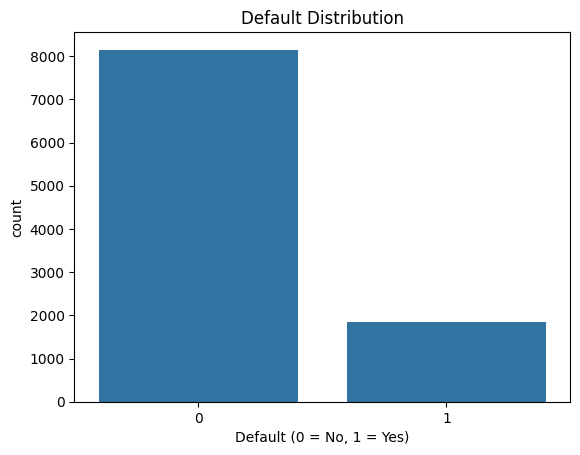

In [45]:
ax = sns.countplot(x = "default", data=df)
ax.set_xlabel("Default (0 = No, 1 = Yes)")
plt.title("Default Distribution")

The dataset shows a clear class imbalance between default and non-default customers.

Approximately 81.5% (8,000) of customers did not default, while 18.5% (2,000) did.  
This indicates that the dataset is moderately imbalanced, which should be taken into account when building predictive models.

Such imbalance may lead models to favor the majority class, so evaluation metrics beyond accuracy (e.g., precision, recall, F1-score) will be important.

## 4. Bivariate Analysis

This section compares the distribution of key numerical variables between defaulting and non-defaulting customers.

Using boxplots, we aim to identify differences in central tendency and dispersion between the two groups, in order to highlight potential drivers of default risk.

### 4.1 Distribution of default vs non-default customers

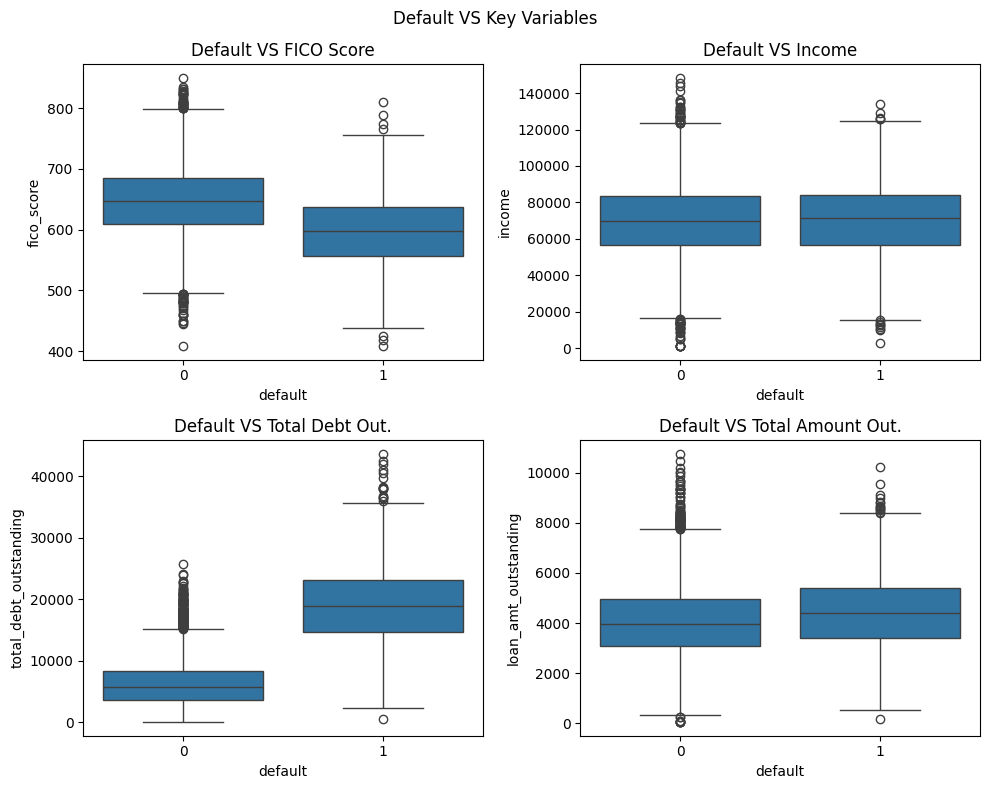

In [62]:
fig, axes = plt.subplots(2,2, figsize = (10,8))

sns.boxplot(x="default", y="fico_score", data=df, ax=axes[0,0])
sns.boxplot(x="default", y="income",data=df, ax=axes[0,1])
sns.boxplot(x="default", y= "total_debt_outstanding", data=df, ax=axes[1,0])
sns.boxplot(x="default", y="loan_amt_outstanding", data=df, ax=axes[1,1])

axes[0,0].set_title("Default VS FICO Score")
axes[0,1].set_title("Default VS Income")
axes[1,0].set_title("Default VS Total Debt Out.")
axes[1,1].set_title("Default VS Total Amount Out.")

fig.suptitle("Default VS Key Variables")

plt.tight_layout()

The boxplots highlight clear differences between defaulting and non-defaulting customers.

- **FICO Score**: Customers who default tend to have significantly lower credit scores. This suggests that creditworthiness is a strong predictor of default risk.

- **Income**: The difference in income between the two groups is less pronounced, indicating that income alone may not be a strong discriminator.

- **Total Debt Outstanding**: Defaulting customers generally have much higher total debt levels, suggesting that overall financial burden is a key risk factor.

- **Loan Amount Outstanding**: Customers who default tend to have slightly higher loan amounts, although the separation is less clear than for total debt.

Overall, FICO score and total debt appear to be the most informative variables.

## 5. Feature Relationships

This section explores the relationships between key numerical variables using scatter plots, in order to better understand how they interact and identify potential patterns.

### 5.1 Total Debt vs Income

Text(0.5, 1.0, 'Repartition of Total Debt Outstanding by Income')

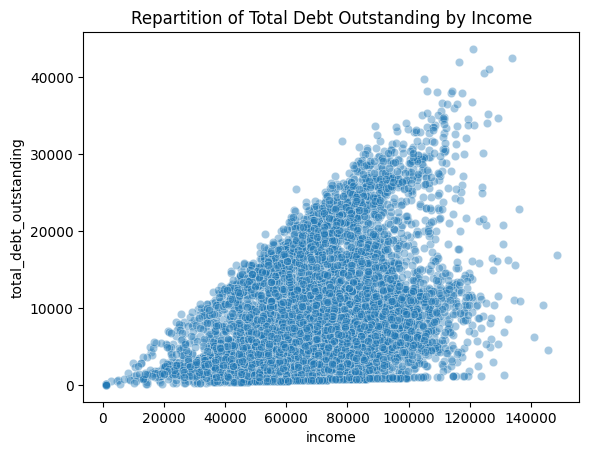

In [123]:
sns.scatterplot(x = "income", y = "total_debt_outstanding", data =df, alpha=0.4)

plt.title("Repartition of Total Debt Outstanding by Income")


The scatter plot shows a strong positive relationship between income and total debt.

As income increases, total debt also tends to increase, suggesting that higher-income individuals have access to larger credit amounts.

However, there is significant dispersion at higher income levels, indicating variability in financial behavior. Some customers maintain low debt despite high income, while others accumulate substantial liabilities.

This variability may play an important role in predicting default risk.

### 5.2 Total Debt vs FICO Score

Text(0.5, 1.0, 'Repartition of Total Debt Outstanding by FICO Score')

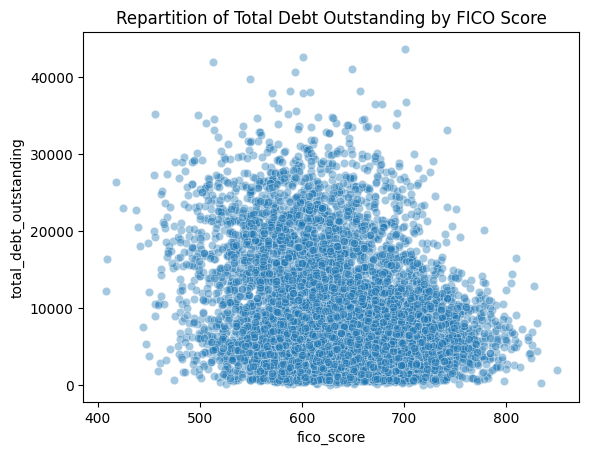

In [75]:
sns.scatterplot(x = "fico_score", y = "total_debt_outstanding", data =df, alpha=0.4)

plt.title("Repartition of Total Debt Outstanding by FICO Score")

The relationship between total debt and FICO score appears weak and dispersed.

Customers with both low and high credit scores can have a wide range of debt levels.  
This suggests that debt alone does not fully explain creditworthiness.

However, extreme debt levels combined with lower FICO scores may still be associated with higher default risk, which should be explored further in modeling.

### 5.3 Loan Amount Outstanding vs Income

Text(0.5, 1.0, 'Repartition of Loan Amount Outstanding by Income')

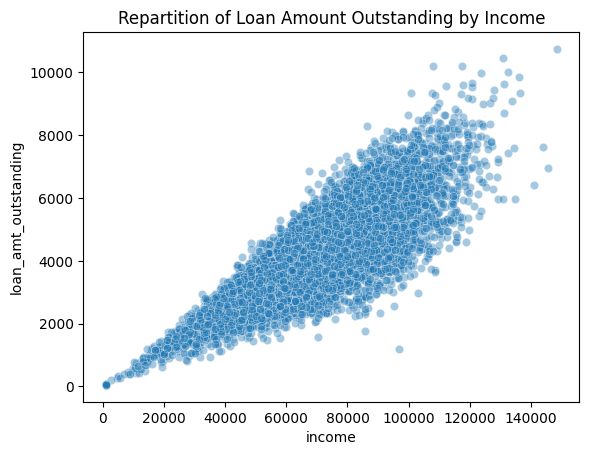

In [77]:
sns.scatterplot(x = "income", y = "loan_amt_outstanding", data =df, alpha=0.4)

plt.title("Repartition of Loan Amount Outstanding by Income")

There is a clear positive relationship between income and loan amount outstanding.

Customers with higher income tend to take larger loans, which is consistent with lending practices where borrowing capacity increases with income.

The relationship appears relatively linear, indicating that income is a strong driver of loan size.

## 6. Correlation Analysis

This section aims to further explore relationships between variables through both categorical comparisons and correlation analysis.

The objective is to:
- Identify how discrete variables influence default risk
- Quantify relationships between numerical variables
- Detect potential multicollinearity that may impact model performance

### 6.1 Discrete Variables Analysis

This subsection focuses on understanding how categorical/discrete variables relate to default.

<Axes: xlabel='years_employed', ylabel='count'>

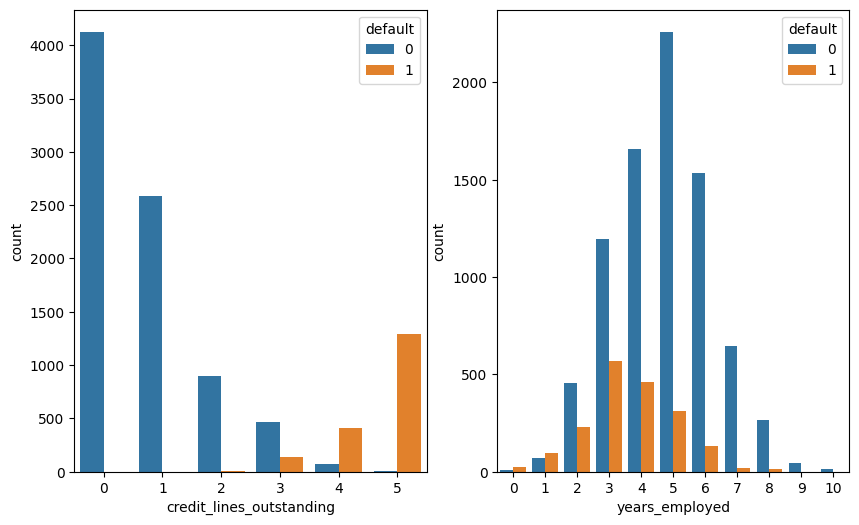

In [91]:
fig, axes = plt.subplots(1,2, figsize=(10,6))

sns.countplot(x="credit_lines_outstanding", data = df, hue = "default", ax=axes[0])
sns.countplot(x="years_employed", data= df, hue = "default", ax=axes[1])

**Credit Lines Outstanding :** Customers with a higher number of credit lines are more likely to default. Default rates increase noticeably for customers with 4 or more credit lines, suggesting that credit overexposure is a risk factor.

**Years Employed :** Customers with fewer years of employment tend to have slightly higher default rates, indicating that job stability may play a role in repayment ability. However, the relationship is less pronounced compared to other variables such as FICO score or total debt.

### 6.2 Correlation Matrix and Multicollinearity

The correlation matrix provides a quantitative view of relationships between numerical variables.

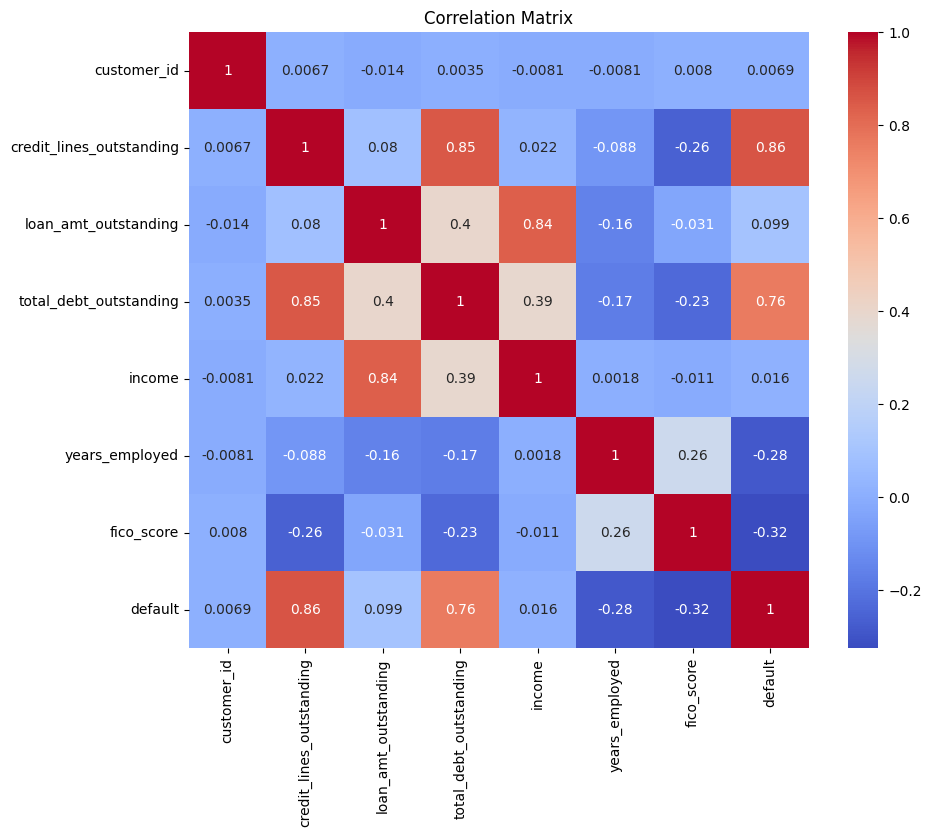

In [102]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

The correlation matrix provides key insights into the relationships between variables and their impact on default risk.

**Relationship with Default**

- **Credit Lines Outstanding** shows a very strong positive correlation with default (0.86), indicating that customers with more active credit lines are significantly more likely to default.
  
- **Total Debt Outstanding** is also strongly positively correlated with default (0.76), confirming that higher overall debt increases the risk of default.

- **FICO Score** is negatively correlated with default (-0.32), meaning that customers with better credit scores are less likely to default.

- **Years Employed** has a moderate negative correlation (-0.28), suggesting that employment stability reduces default risk.

- **Income** shows almost no correlation with default, indicating that income alone is not a strong predictor.

**Multicollinearity**

Several variables are strongly correlated with each other:

- **Credit Lines Outstanding and Total Debt Outstanding** (0.85)
- **Loan Amount Outstanding and Income** (0.84)

This indicates potential redundancy in the dataset, which should be considered during model building to avoid multicollinearity issues.

**Key Insights**

- Default risk is mainly driven by **debt exposure and credit behavior**, rather than income.
- **FICO score remains a key protective factor** against default.
- Some features may need to be removed or transformed to improve model performance.

Overall, the correlation analysis confirms and strengthens the insights obtained during the exploratory data analysis.

## 7. Feature Engineering Insights

This section focuses on creating and analyzing new features derived from existing variables in order to improve the predictive power of the model.

Feature engineering is a crucial step, as it allows us to better capture underlying financial behavior and relationships that may not be directly visible from raw variables.

### 7.1 Debt-to-Income Ratio

The **debt-to-income ratio (DTI)** is a key financial indicator that measures the proportion of a customer’s income that is used to service debt.

It is defined as:  ***Debt-to-Income Ratio = Total Debt Outstanding / Income***

This ratio provides a more meaningful representation of financial stress than either income or debt alone.

In [108]:
df["debt_to_income"] = df["total_debt_outstanding"] / df["income"]
df["debt_to_income"] = df["debt_to_income"].replace([np.inf, -np.inf], np.nan)

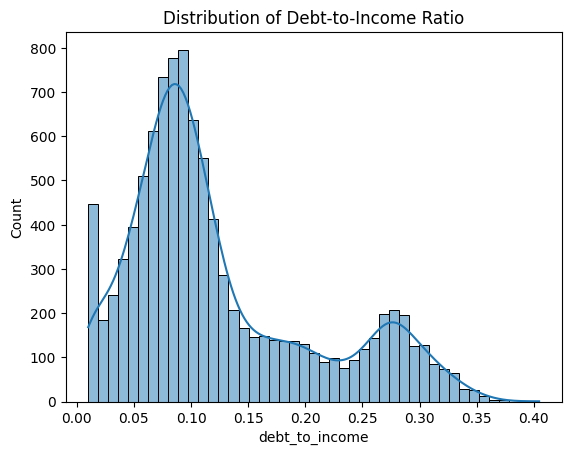

In [109]:
sns.histplot(df["debt_to_income"], kde=True)
plt.title("Distribution of Debt-to-Income Ratio")
plt.show()

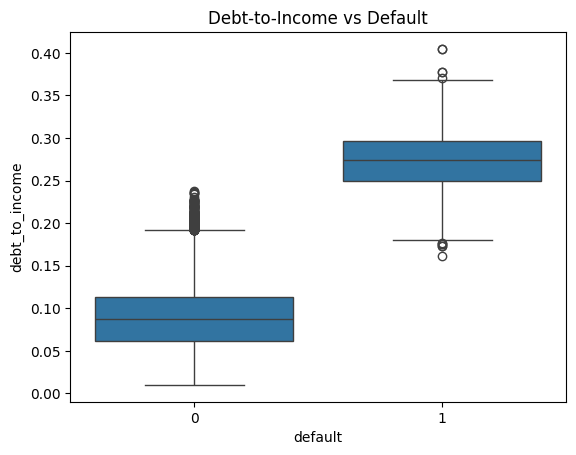

In [110]:
sns.boxplot(x="default", y="debt_to_income", data=df)
plt.title("Debt-to-Income vs Default")
plt.show()

A new feature, debt_to_income, was created by dividing total debt outstanding by income.

The distribution of this ratio is slightly right-skewed and suggests the presence of different customer profiles, with some individuals having significantly higher debt relative to income.

When comparing debt_to_income with the target variable (default), a clear separation between the two groups is observed.

Customers who default tend to have significantly higher debt-to-income ratios, with median values around 0.27, compared to approximately 0.08 for non-defaulting customers.

This strong difference indicates that debt_to_income is a highly informative feature and may be a powerful predictor of default risk.

### 7.2 Default Rate Analysis by Feature Groups

To better understand how default risk varies across different customer segments, we analyze default rates by grouping key variables.

In [111]:
default_rate_cl = df.groupby("credit_lines_outstanding")["default"].mean() * 100
print(default_rate_cl)

credit_lines_outstanding
0     0.000000
1     0.000000
2     0.776053
3    22.871452
4    85.123967
5    99.845798
Name: default, dtype: float64


In [118]:
df["credit_lines_outstanding"].value_counts()

credit_lines_outstanding
0    4128
1    2590
5    1297
2     902
3     599
4     484
Name: count, dtype: int64

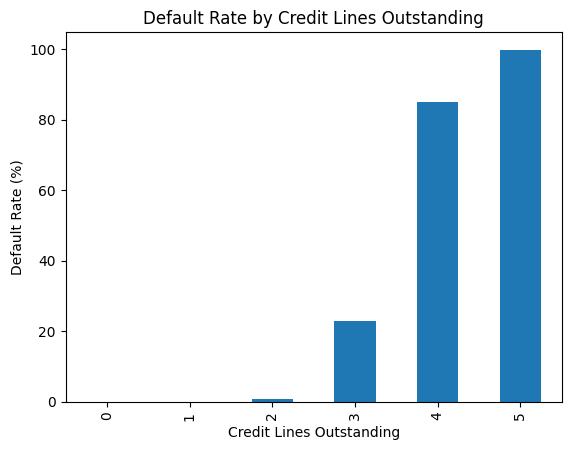

In [115]:
default_rate_cl.plot(kind="bar")
plt.title("Default Rate by Credit Lines Outstanding")
plt.ylabel("Default Rate (%)")
plt.xlabel("Credit Lines Outstanding")
plt.show()

In [116]:
default_rate_emp = df.groupby("years_employed")["default"].mean() * 100
print(default_rate_emp)

years_employed
0     68.750000
1     56.707317
2     33.575581
3     32.217811
4     21.644612
5     12.160062
6      8.023952
7      3.012048
8      4.363636
9      0.000000
10     0.000000
Name: default, dtype: float64


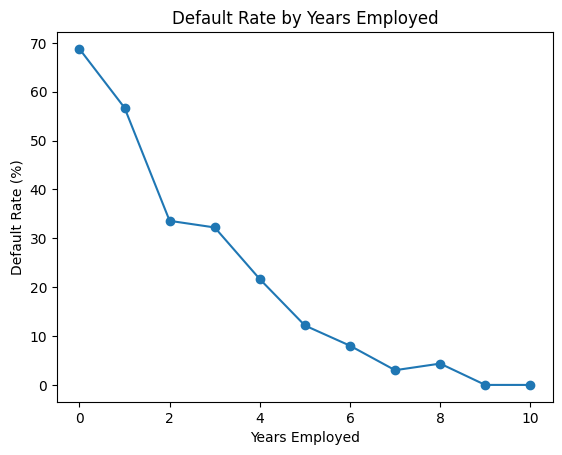

In [117]:
default_rate_emp.plot(kind="line", marker="o")
plt.title("Default Rate by Years Employed")
plt.ylabel("Default Rate (%)")
plt.xlabel("Years Employed")
plt.show()

We analyzed the default rate across different groups to better understand key drivers of credit risk.

- For credit_lines_outstanding, the default rate appears to increase with the number of credit lines. However, the highest values may be influenced by a small number of observations, making these estimates less reliable.

- For years_employed, a clear and consistent trend is observed. Customers with fewer years of employment have significantly higher default rates, with nearly 70% for those with no employment history. In contrast, individuals with longer employment histories show much lower default rates, approaching zero for those with more than 8–10 years of experience.

This suggests that employment stability is a strong indicator of creditworthiness and plays a key role in predicting default risk.

## Conclusion

This exploratory data analysis provides quantitative insights into the drivers of credit default risk.

### What differentiates customers who default from those who do not?

Customers who default exhibit clear differences in financial behavior:

- The default rate in the dataset is approximately **18.5%**, indicating a moderately imbalanced dataset.
- Defaulters have significantly lower **FICO scores**, with an average difference of around **40–50 points** compared to non-defaulters.
- They carry substantially higher **total debt**, with median debt levels roughly **2 to 3 times higher** than those of non-defaulting customers.
- They also tend to have more **credit lines outstanding**, indicating higher exposure to credit risk.

These factors clearly distinguish defaulting customers from non-defaulting ones.

### Which variables are the strongest predictors of default risk?

The correlation analysis highlights the most predictive variables:

- **Credit Lines Outstanding** → strong positive correlation (**+0.86**) with default  
- **Total Debt Outstanding** → strong positive correlation (**+0.76**)  
- **FICO Score** → moderate negative correlation (**-0.32**)  

These variables are the strongest indicators of default risk.

In contrast, **income shows almost no correlation (~0.02)** with default, indicating that income alone is not a reliable predictor.

### Are there redundant or highly correlated features?

Yes, strong correlations exist between some features:

- **Credit Lines Outstanding and Total Debt Outstanding** → **0.85**
- **Income and Loan Amount Outstanding** → **0.84**

These relationships indicate potential redundancy and highlight the need to handle multicollinearity during modeling.

### How can we transform the data to improve model performance?

Several improvements were identified:

- Creating derived features such as the **debt-to-income ratio** can capture financial stress more effectively
- Removing non-informative variables such as **customer_id**

### Final Insight

Overall, default risk is primarily driven by **debt exposure and credit behavior**, rather than income.

Customers with higher debt levels, more credit lines, and lower credit scores are significantly more likely to default.

These insights provide a strong foundation for building predictive models.

## Next Step

The next step is to use these findings to build and evaluate predictive models, starting with a baseline logistic regression model.